# Project: Customer Segmentation for Targeted EV & Hybrid Marketing
## Unsupervised Machine Learning with K-Means

**Business Objective:**
An automotive manufacturer is accelerating its transition to Hybrid and Electric Vehicles (EVs), including the introduction of new models like the bZ, bZ Woodlands, C-HR, and Highlander EV. The marketing team needs to intelligently identify which current internal combustion engine (ICE) owners are prime candidates for early-reservation and upgrade campaigns, optimizing marketing ROI and conversion rates.

**Methodology:**
This project utilizes **Unsupervised Machine Learning (K-Means Clustering)** to analyze a simulated CRM database of 5,000 customers. Unlike supervised learning, which predicts a specific target, unsupervised learning automatically groups customers into distinct behavioral profiles based on hidden, multidimensional patterns (such as vehicle age, annual mileage, local gas prices, and household income).

By translating these mathematical clusters into actionable business logic, we can precisely determine who should receive targeted promotional emails and who should remain in the standard brand awareness lifecycle.

In [11]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings

# Suppress minor warnings for a clean output
warnings.filterwarnings('ignore')

# ==========================================
# PHASE 1: GENERATE SYNTHETIC CUSTOMER LOYALTY DATA
# ==========================================
print("Generating synthetic owner loyalty database...")
np.random.seed(42)
num_customers = 5000

# Simulating a corporate CRM database of current internal combustion engine (ICE) owners
data = {
    'current_vehicle_age_years': np.random.uniform(1, 15, size=num_customers),
    'annual_mileage': np.random.normal(13500, 5000, size=num_customers),
    'dealership_service_visits_yr': np.random.poisson(lam=2, size=num_customers),
    'local_avg_gas_price': np.random.uniform(3.10, 5.80, size=num_customers), # Higher gas prices drive hybrid interest
    'household_income_k': np.random.normal(90, 35, size=num_customers)
}

df = pd.DataFrame(data)

# Clean up any unrealistic negative values generated by the normal distribution
df['annual_mileage'] = df['annual_mileage'].clip(lower=2000)
df['household_income_k'] = df['household_income_k'].clip(lower=35)

# ==========================================
# PHASE 2: DATA PREPROCESSING (STANDARDIZATION)
# ==========================================
print("Standardizing feature scales for K-Means distance calculations...")
# CRITICAL STEP: K-Means relies on measuring physical distance between data points.
# If we don't scale the data, "annual_mileage" (e.g., 15,000) will completely overpower
# "current_vehicle_age_years" (e.g., 5). StandardScaler forces everything onto an equal playing field.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

# ==========================================
# PHASE 3: TRAIN THE K-MEANS CLUSTERING MODEL
# ==========================================
print("Training the Unsupervised K-Means Algorithm...\n")
# We are asking the AI to find 4 distinct customer personas in the data
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

# Assign every customer to one of the 4 clusters
df['customer_segment_id'] = kmeans.fit_predict(scaled_features)

# ==========================================
# PHASE 4: BUSINESS TRANSLATION & PROFILING
# ==========================================
# Calculate the average metrics for each cluster to understand who these people are
cluster_profiles = df.groupby('customer_segment_id').mean().round(1)

print("--- CUSTOMER SEGMENT PROFILES ---")
print(cluster_profiles)
print("\n--- CORPORATE MARKETING TRANSLATION ---")

# Let's assign business logic to the clusters based on their characteristics
cluster_action_map = {}
for i in range(num_clusters):
    profile = cluster_profiles.loc[i]

    # Logic to define high-value hybrid and EV transition targets:
    if profile['local_avg_gas_price'] > 4.5 and profile['annual_mileage'] >= 12000:
        segment_name = "Prime Hybrid Upgrade Candidates (High Mileage / High Gas Costs)"
        action = "Send targeted lease offers for Prius, Camry Hybrid, or the all-hybrid RAV4."
    elif profile['household_income_k'] > 90 and profile['current_vehicle_age_years'] < 6:
        segment_name = "Prime EV Targets (High Income / Tech Adopters)"
        action = "Target with BZ, BZ Woodlands, CHR, and Highlander EV early-reservation campaigns."
    elif profile['current_vehicle_age_years'] >= 10 and profile['dealership_service_visits_yr'] >= 1.5:
        segment_name = "Aging Vehicle Loyalists"
        action = "Provide trade-in equity evaluation; emphasize new safety tech."
    elif profile['household_income_k'] > 95 and profile['annual_mileage'] < 13000:
        segment_name = "Premium Low-Mileage Drivers"
        action = "Target for Plug-in Hybrid (PHEV) or luxury trim transitions."
    else:
        segment_name = "General Audience (Status Quo)"
        action = "Maintain standard brand awareness lifecycle emails."

    cluster_action_map[i] = action
    print(f"\nCluster {i}: {segment_name}")
    print(f"-> Profile: Avg Age {profile['current_vehicle_age_years']} yrs | Mileage: {profile['annual_mileage']:,.0f} | Gas: ${profile['local_avg_gas_price']}/gal")
    print(f"-> Corporate Action: {action}")

print("==========================================")

Generating synthetic owner loyalty database...
Standardizing feature scales for K-Means distance calculations...
Training the Unsupervised K-Means Algorithm...

--- CUSTOMER SEGMENT PROFILES ---
                     current_vehicle_age_years  annual_mileage  \
customer_segment_id                                              
0                                          3.6         13916.9   
1                                         10.3         12297.1   
2                                         11.1         13771.4   
3                                          7.6         13810.5   

                     dealership_service_visits_yr  local_avg_gas_price  \
customer_segment_id                                                      
0                                             1.5                  4.4   
1                                             1.6                  5.2   
2                                             1.6                  3.7   
3                                     

### Technical Highlight: Data Standardization

A critical step in this pipeline is **Phase 2 (Standardization)**.

Because K-Means clustering is a distance-based algorithm (relying on Euclidean distance), features with larger numerical magnitudes (like `annual_mileage` averaging 13,500) will mathematically dominate features with smaller magnitudes (like `current_vehicle_age_years` averaging 5). Applying `StandardScaler` ensures all features are normalized to an equal playing field (mean of 0, variance of 1), allowing the model to weigh behavioral patterns accurately without being skewed by arbitrary unit scales.

### Stakeholder Communication: Visualizations & Actionable Deliverables

Data science models must be interpretable to drive business value. To effectively communicate these abstract clusters to the Marketing Operations team, we employ two visualization techniques:
1. **Principal Component Analysis (PCA):** Reduces the 5-dimensional data into 2 dimensions, allowing us to visually validate the distinctness of our customer segments on a scatter plot.
2. **Cluster Heatmaps:** Provides an immediate, color-coded visual profile of the defining characteristics of each segment.

Finally, the algorithm's logic is mapped to tangible business actions and exported directly into a CSV deliverable (`targeted_marketing_lists.csv`), ready for ingestion by the enterprise email marketing system.

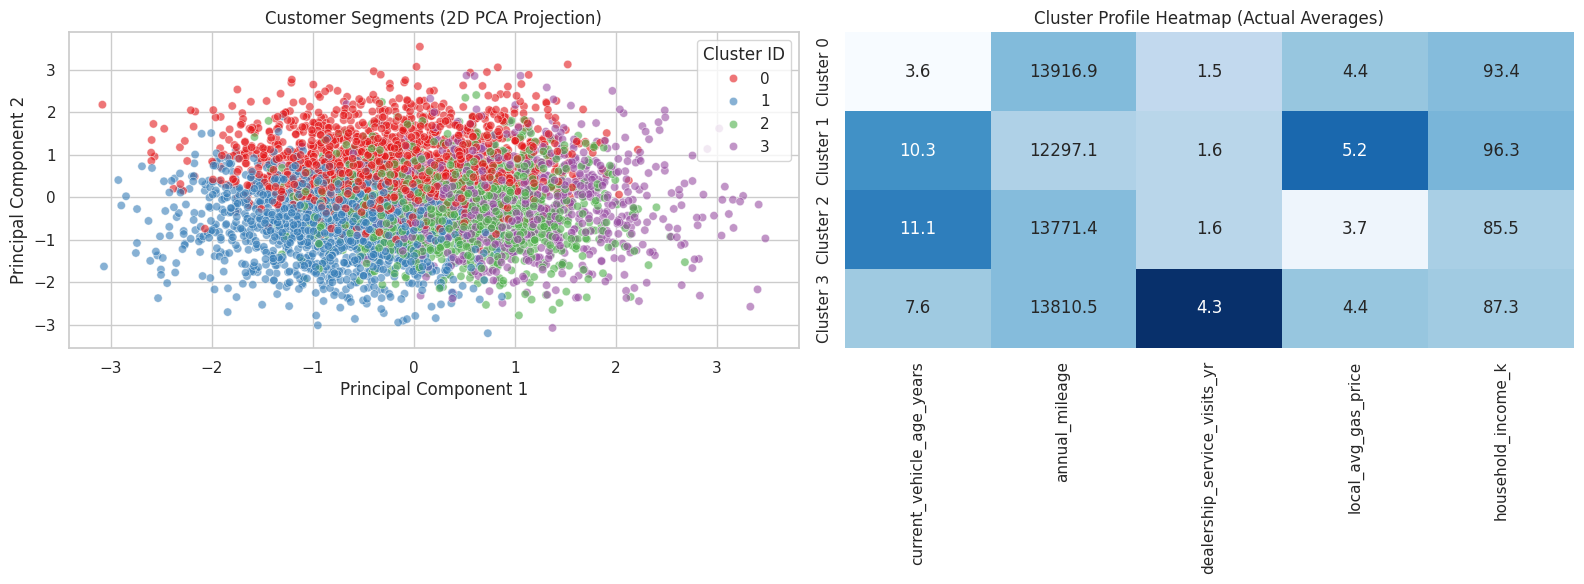

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Set up the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# --- Subplot 1: 2D Cluster Visualization using PCA ---
# We use PCA (Principal Component Analysis) to compress our 5-dimensional data into 2 dimensions.
# This allows us to plot the customers on a standard X/Y scatter plot to see how distinct the groups are.
plt.subplot(1, 2, 1)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

sns.scatterplot(
    x=pca_features[:, 0],
    y=pca_features[:, 1],
    hue=df['customer_segment_id'],
    palette='Set1',
    alpha=0.6
)
plt.title("Customer Segments (2D PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster ID")

# --- Subplot 2: Heatmap of Cluster Centers ---
# A heatmap provides a highly visual way to see which features define which clusters.
plt.subplot(1, 2, 2)
# Scale the profiles to see relative highs/lows more clearly, but annotate with actual values
normalized_profiles = pd.DataFrame(scaler.transform(cluster_profiles), columns=cluster_profiles.columns)
sns.heatmap(
    normalized_profiles,
    annot=cluster_profiles,
    fmt=".1f",
    cmap="Blues",
    cbar=False,
    yticklabels=[f"Cluster {i}" for i in range(num_clusters)]
)
plt.title("Cluster Profile Heatmap (Actual Averages)")

plt.tight_layout()
plt.show()

In [14]:
# ==========================================
# PHASE 5: EXPORTING THE DELIVERABLE
# ==========================================
# In the real world, the Marketing Ops team needs a list of customers and what to send them.

# 1. Map the actions we generated dynamically in Phase 4 directly to the DataFrame
df['marketing_action'] = df['customer_segment_id'].map(cluster_action_map)

# 2. Save the final list to a CSV
export_filename = "targeted_marketing_lists.csv"
df.to_csv(export_filename, index=False)

print(f"\nSuccess! Exported {len(df):,} customer records to '{export_filename}'.")
print("Here is a preview of the final deliverable for the email system:\n")
display(df[['current_vehicle_age_years', 'annual_mileage', 'customer_segment_id', 'marketing_action']].head())


Success! Exported 5,000 customer records to 'targeted_marketing_lists.csv'.
Here is a preview of the final deliverable for the email system:



,current_vehicle_age_years,annual_mileage,customer_segment_id,marketing_action
0,6.243562,10515.128566,0,"Target with BZ, BZ Woodlands, CHR, and Highlan..."
1,14.310000,2000.000000,1,"Send targeted lease offers for Prius, Camry Hy..."
2,11.247915,11438.896275,1,"Send targeted lease offers for Prius, Camry Hy..."
3,9.381219,18067.368660,2,Provide trade-in equity evaluation; emphasize ...
4,3.184261,16188.149515,0,"Target with BZ, BZ Woodlands, CHR, and Highlan..."


### Phase 6: Propensity Modeling (Supervised Learning Extension)

Now that we have successfully clustered our users, let's tie this back to Supervised Learning. Imagine we ran this campaign last year. We can use the historical response data to train a predictive model (like a **Random Forest**) to calculate the exact *probability* (propensity score) that a specific customer will convert.

This shows a complete end-to-end pipeline: using Unsupervised Learning to discover segments, and Supervised Learning to predict future outcomes based on those segments.

Simulating historical conversion data...
Training Random Forest Classifier...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       705
           1       0.95      0.82      0.88       295

    accuracy                           0.93      1000
   macro avg       0.94      0.90      0.92      1000
weighted avg       0.93      0.93      0.93      1000



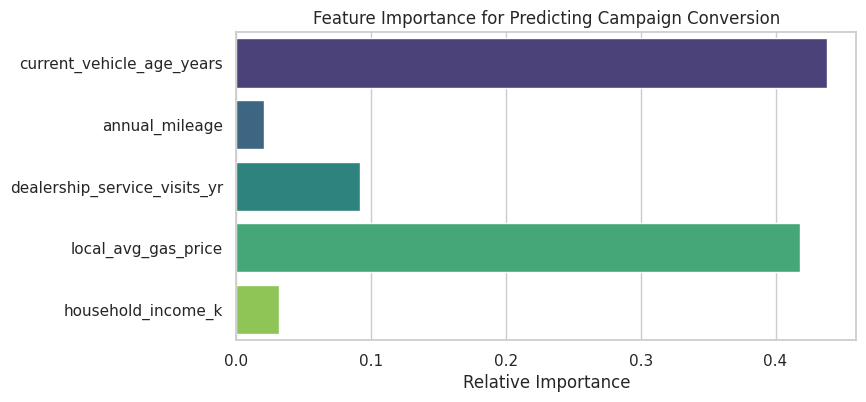

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print("Simulating historical conversion data...")
# We'll simulate that our 'Prime' targets (Clusters 0 and 1) had a 60% conversion rate,
# while the rest had a 10% conversion rate.
np.random.seed(42)
df['converted'] = np.where(df['customer_segment_id'].isin([0, 1]),
                           np.random.choice([0, 1], size=len(df), p=[0.4, 0.6]),
                           np.random.choice([0, 1], size=len(df), p=[0.9, 0.1]))

# Define our features (X) and target label (y)
features = ['current_vehicle_age_years', 'annual_mileage', 'dealership_service_visits_yr', 'local_avg_gas_price', 'household_income_k']
X = df[features]
y = df['converted']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_model.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Feature Importance Visualization
importances = rf_model.feature_importances_
plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=features, palette='viridis')
plt.title('Feature Importance for Predicting Campaign Conversion')
plt.xlabel('Relative Importance')
plt.show()

### Phase 7: Interactive Web Dashboard (Gradio)

To make these insights accessible to non-technical stakeholders, we can wrap our clustering logic into a lightweight **Gradio** web application.

In [10]:
!pip install -q gradio

Overwriting app.py


### Run the Gradio App

Run the cell below to launch the Gradio app directly within the notebook. Gradio will also generate a public share link that you can send to stakeholders!

In [17]:
import gradio as gr

print("Launching Gradio App...")

def get_segment_and_action(age, mileage, visits, gas_price, income):
    segment = "General Audience (Status Quo)"
    action = "Maintain standard brand awareness lifecycle emails."

    if gas_price > 4.5 and mileage >= 12000:
        segment = "Prime Hybrid Upgrade Candidates (High Mileage / High Gas Costs)"
        action = "Send targeted lease offers for Prius, Camry Hybrid, or the all-hybrid RAV4."
    elif income > 90 and age < 6:
        segment = "Prime EV Targets (High Income / Tech Adopters)"
        action = "Target with BZ, BZ Woodlands, CHR, and Highlander EV early-reservation campaigns."
    elif age >= 10 and visits >= 1.5:
        segment = "Aging Vehicle Loyalists"
        action = "Provide trade-in equity evaluation; emphasize new safety tech."

    return segment, action

with gr.Blocks(title="EV & Hybrid Marketing Targeter") as demo:
    gr.Markdown("# 🚗 EV & Hybrid Marketing Targeter")
    gr.Markdown("Adjust the customer profile below to see which marketing segment they belong to.")

    with gr.Row():
        age = gr.Slider(1, 20, value=5, step=1, label="Current Vehicle Age (Years)")
        mileage = gr.Slider(2000, 30000, value=12000, step=100, label="Annual Mileage")
        visits = gr.Slider(0, 10, value=2, step=1, label="Dealership Service Visits")
    with gr.Row():
        gas_price = gr.Slider(2.00, 7.00, value=4.50, step=0.1, label="Local Avg Gas Price ($)")
        income = gr.Slider(30, 250, value=90, step=1, label="Household Income ($k)")

    btn = gr.Button("Analyze Customer")
    segment_output = gr.Textbox(label="🎯 Assigned Segment")
    action_output = gr.Textbox(label="Recommended Action")

    btn.click(fn=get_segment_and_action,
              inputs=[age, mileage, visits, gas_price, income],
              outputs=[segment_output, action_output])

demo.launch(share=True)

Launching Gradio App...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://da4f0bc965437528b9.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Appendix: Validating the Number of Clusters

In a real-world scenario, we don't always know the ideal number of segments beforehand. To prove that $K=4$ is a mathematically sound choice, we can use the **Elbow Method** (which looks at the sum of squared distances) and the **Silhouette Score** (which measures how similar an object is to its own cluster compared to other clusters).

A higher Silhouette Score and a distinct "elbow" (inflection point) in the inertia plot indicate a good number of clusters.

Calculating Inertia and Silhouette Scores for K=2 through K=7...


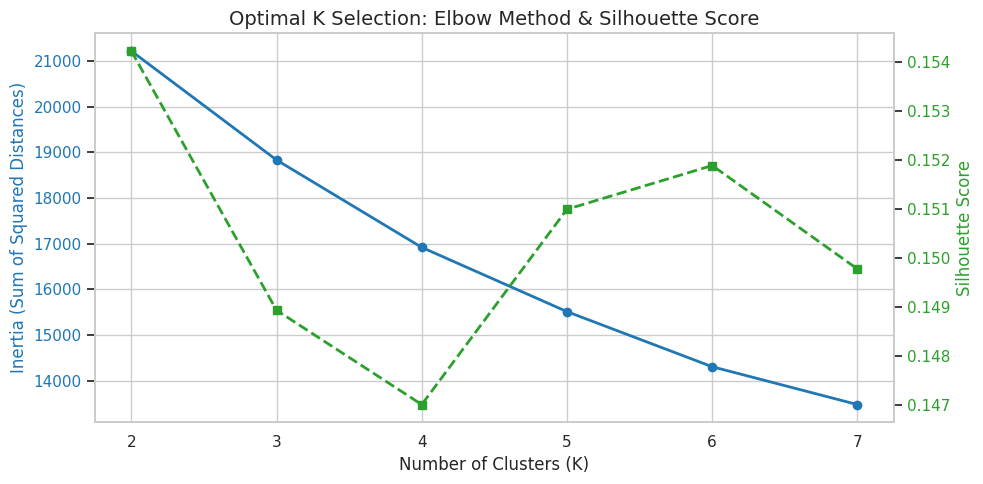

In [15]:
from sklearn.metrics import silhouette_score

print("Calculating Inertia and Silhouette Scores for K=2 through K=7...")

inertia = []
silhouette_scores = []
K_range = range(2, 8)

# Test different values of K
for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_test.fit_predict(scaled_features)

    inertia.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, cluster_labels))

# Create a dual-axis plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot 1: Elbow Method (Inertia)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Sum of Squared Distances)', color=color)
ax1.plot(K_range, inertia, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Plot 2: Silhouette Score
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:green'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimal K Selection: Elbow Method & Silhouette Score', fontsize=14)
fig.tight_layout()
plt.grid(False) # Turn off grid for the secondary axis to avoid clutter
plt.show()